In [81]:
# Кейс №57: Классификация спама по тексту электронного письма
# Автор: студентка группы ЕТ-142 Ермакова Софья Юрьевна
# Коды для первичного анализа набора текстовых данных

# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import os

# Загрузка используемого датасета txt с табуляцией с гугл диска
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/My Drive/sms+spam+collection/SMSSpamCollection", sep="\t", header=None, names=["label", "text"])

# Сохраняем оригинал для сравнения после очистки (этап 1)
df["text_original"] = df["text"].copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
# Изменение ham/spam на 0/1
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Сохраняем как CSV
df.to_csv("sms_spam.csv", index=False)

print(df.head())
print(f"\nВсего: {len(df)}")
print(df["label"].value_counts())

   label                                               text  \
0      0  Go until jurong point, crazy.. Available only ...   
1      0                      Ok lar... Joking wif u oni...   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...   
3      0  U dun say so early hor... U c already then say...   
4      0  Nah I don't think he goes to usf, he lives aro...   

                                       text_original  
0  Go until jurong point, crazy.. Available only ...  
1                      Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup fina...  
3  U dun say so early hor... U c already then say...  
4  Nah I don't think he goes to usf, he lives aro...  

Всего: 5572
label
0    4825
1     747
Name: count, dtype: int64


In [83]:
# Проверка на наличие пропусков

print("Пропуски в колонках:")
print(df.isnull().sum())

# Проверка пустых строк
empty_texts = df["text"].str.strip().eq("").sum()
print(f"\nПустых текстов: {empty_texts}")

# Проверка меток
print(f"\nРаспределение меток:")
print(df["label"].value_counts())
print(f"Некорректных меток: {df['label'].isna().sum()}")

if df.isnull().sum().sum() == 0 and empty_texts == 0:
    print(" Пропусков нет")
else:
    print(" Есть проблемы")

Пропуски в колонках:
label            0
text             0
text_original    0
dtype: int64

Пустых текстов: 0

Распределение меток:
label
0    4825
1     747
Name: count, dtype: int64
Некорректных меток: 0
 Пропусков нет


In [84]:
# Этап 1. Очистка текста

def clean_text(text):
    # 1. Нижний регистр
    text = text.lower()
    # 2. Удаление пунктуации и спецсимволов (цифры оставляем)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    # 3. Удаление лишних пробелов
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["text"] = df["text"].apply(clean_text)

# Удаляем пустые строки, если появились
df = df[df["text"] != ""].reset_index(drop=True)

# Результаты
print("Примеры до и после очистки")

for i in [0, 1, 2]:
    print(f"\nПример {i+1} (label = {df['label'].iloc[i]}):")
    print(f"  До:   {df['text_original'].iloc[i][:150]}")
    print(f"  После: {df['text'].iloc[i][:150]}")

print(f"\nВсего сообщений после очистки: {len(df)}")

Примеры до и после очистки

Пример 1 (label = 0):
  До:   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  После: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Пример 2 (label = 0):
  До:   Ok lar... Joking wif u oni...
  После: ok lar joking wif u oni

Пример 3 (label = 1):
  До:   Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075ove
  После: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt ratetcs apply 08452810075over18s

Всего сообщений после очистки: 5570


In [85]:
# Этап 2. Токенизация и лемматизация

nltk.download('punkt_tab')
nltk.download('wordnet')

lemm = WordNetLemmatizer()

df["tokens"] = df["text"].apply(lambda x: [lemm.lemmatize(w) for w in word_tokenize(x)])
df["text_lemmatized"] = df["tokens"].apply(lambda x: " ".join(x))

print(df[["label", "text", "text_lemmatized"]].head())
print(f"\nВсего: {len(df)}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


   label                                               text  \
0      0  go until jurong point crazy available only in ...   
1      0                            ok lar joking wif u oni   
2      1  free entry in 2 a wkly comp to win fa cup fina...   
3      0        u dun say so early hor u c already then say   
4      0  nah i dont think he goes to usf he lives aroun...   

                                     text_lemmatized  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  
3        u dun say so early hor u c already then say  
4  nah i dont think he go to usf he life around h...  

Всего: 5570


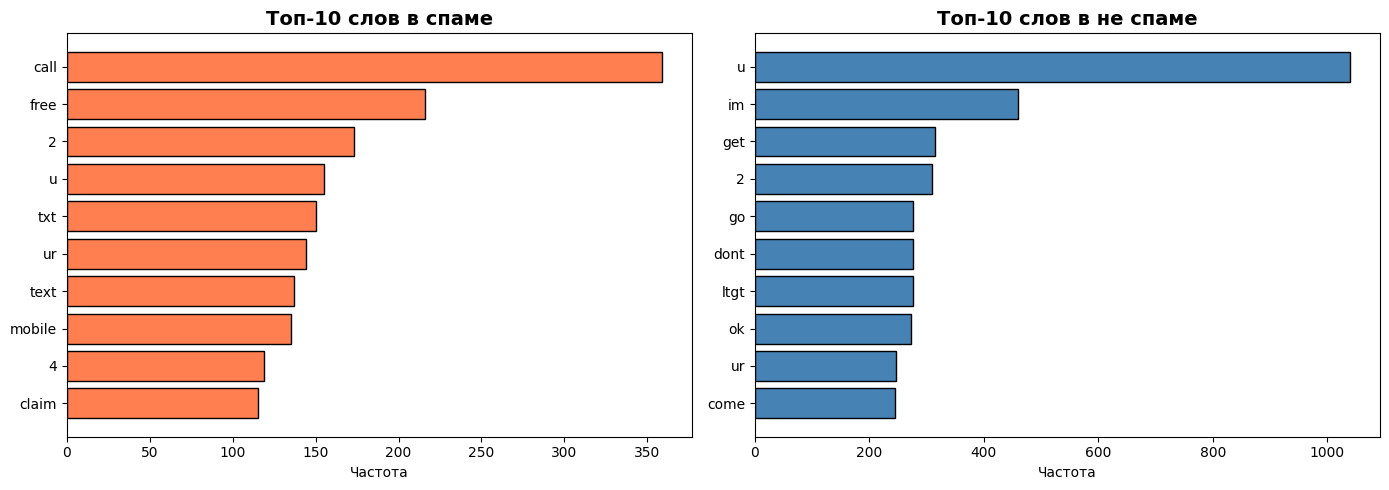

In [86]:
# Этап 3. Удаление стоп-слов и подсчёт частоты слов

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

# Удаление стоп-слов
df["tokens_no_stop"] = df["tokens"].apply(
    lambda x: [w for w in x if w not in stop_words]
)

# Частоты
spam_words = [w for tokens in df[df["label"] == 1]["tokens_no_stop"] for w in tokens]
ham_words  = [w for tokens in df[df["label"] == 0]["tokens_no_stop"] for w in tokens]

spam_freq = Counter(spam_words).most_common(10)
ham_freq  = Counter(ham_words).most_common(10)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Спам
words, counts = zip(*spam_freq)
ax1.barh(range(10), counts[::-1], color="coral", edgecolor="black")
ax1.set_yticks(range(10))
ax1.set_yticklabels(words[::-1])
ax1.set_title("Топ-10 слов в спаме", fontsize=14, fontweight="bold")
ax1.set_xlabel("Частота")

# Не спам
words, counts = zip(*ham_freq)
ax2.barh(range(10), counts[::-1], color="steelblue", edgecolor="black")
ax2.set_yticks(range(10))
ax2.set_yticklabels(words[::-1])
ax2.set_title("Топ-10 слов в не спаме", fontsize=14, fontweight="bold")
ax2.set_xlabel("Частота")

plt.tight_layout()
plt.show()

In [87]:
# TF-IDF векторизация

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

X = tfidf.fit_transform(df["text_lemmatized"])
y = df["label"].values  # numpy array

print("TF-IDF векторизация")
print(f"Размер матрицы: {X.shape}")
print(f"  Строк (сообщений): {X.shape[0]}")
print(f"  Признаков (токенов): {X.shape[1]}")

# Топ-10 слов спама по среднему TF-IDF
spam_idx = y == 1
ham_idx = y == 0

spam_tfidf = np.array(X[spam_idx].mean(axis=0)).flatten()
ham_tfidf  = np.array(X[ham_idx].mean(axis=0)).flatten()

feature_names = tfidf.get_feature_names_out()

top_spam = spam_tfidf.argsort()[::-1][:10]
print("\nТоп-10 слов по среднему TF-IDF в спаме:")
for i in top_spam:
    print(f"  {feature_names[i]}: {spam_tfidf[i]:.4f}")

top_ham = ham_tfidf.argsort()[::-1][:10]
print("\nТоп-10 слов по среднему TF-IDF в не спаме:")
for i in top_ham:
    print(f"  {feature_names[i]}: {ham_tfidf[i]:.4f}")

TF-IDF векторизация
Размер матрицы: (5570, 3000)
  Строк (сообщений): 5570
  Признаков (токенов): 3000

Топ-10 слов по среднему TF-IDF в спаме:
  to: 0.0695
  call: 0.0550
  free: 0.0415
  your: 0.0399
  txt: 0.0323
  or: 0.0309
  you: 0.0308
  for: 0.0304
  now: 0.0303
  text: 0.0295

Топ-10 слов по среднему TF-IDF в не спаме:
  you: 0.0403
  to: 0.0309
  the: 0.0270
  it: 0.0251
  in: 0.0242
  me: 0.0226
  is: 0.0213
  and: 0.0211
  my: 0.0208
  ok: 0.0173


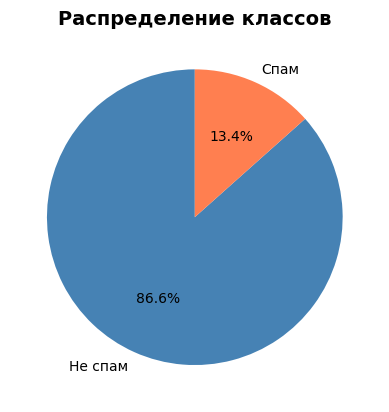

Не спам: 4823 (86.6%)
Спам:    747 (13.4%)
Соотношение: 1:6.5


In [92]:
# Этап 5. Распределение классов и длин текстов

# Диаграмма распределения классов

plt.pie(counts, labels=["Не спам", "Спам"], autopct="%1.1f%%",
        colors=["steelblue", "coral"], startangle=90)
plt.title("Распределение классов", fontsize=14, fontweight="bold")
plt.show()

print(f"Не спам: {counts[0]} ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Спам:    {counts[1]} ({counts[1]/counts.sum()*100:.1f}%)")
print(f"Соотношение: 1:{counts[0]/counts[1]:.1f}")

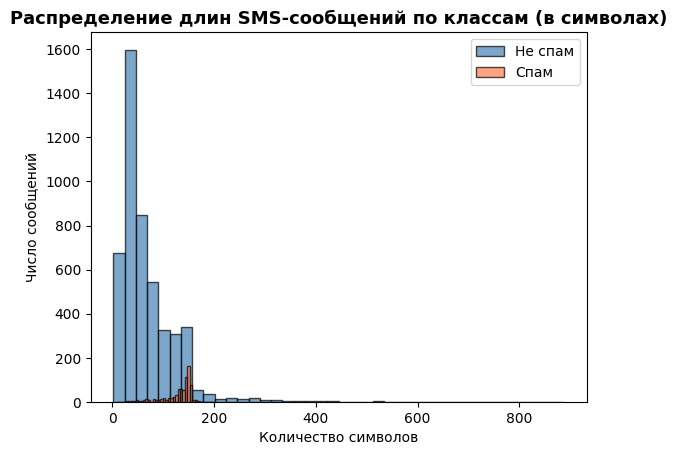

Средняя длина (не спам): 67 символов
Средняя длина (спам):    132 символов
Медиана (не спам):        49 символов
Медиана (спам):           142 символов


In [94]:
# Длина в символах
df["len_chars"] = df["text"].apply(len)

# Разделяем
ham_len = df[df["label"] == 0]["len_chars"]
spam_len = df[df["label"] == 1]["len_chars"]

# Гистограмма
plt.hist(ham_len, bins=40, alpha=0.7, color="steelblue", label="Не спам", edgecolor="black")
plt.hist(spam_len, bins=40, alpha=0.7, color="coral", label="Спам", edgecolor="black")
plt.title("Распределение длин SMS-сообщений по классам (в символах)", fontsize=13, fontweight="bold")
plt.xlabel("Количество символов")
plt.ylabel("Число сообщений")
plt.legend()
plt.show()

# Статистика
print(f"Средняя длина (не спам): {ham_len.mean():.0f} символов")
print(f"Средняя длина (спам):    {spam_len.mean():.0f} символов")
print(f"Медиана (не спам):        {ham_len.median():.0f} символов")
print(f"Медиана (спам):           {spam_len.median():.0f} символов")

In [102]:
# Статистика длин сообщений по классам (символы)

print("Статистика длин сообщений по классам (символы)")
print(f"{'Показатель':<20} {'Не спам':<12} {'Спам':<12}")
print(f"{'Среднее':<20} {ham_len.mean():<12.0f} {spam_len.mean():<12.0f}")
print(f"{'Медиана':<20} {ham_len.median():<12.0f} {spam_len.median():<12.0f}")
print(f"{'Минимум':<20} {ham_len.min():<12} {spam_len.min():<12}")
print(f"{'Максимум':<20} {ham_len.max():<12} {spam_len.max():<12}")
print(f"{'Стд. откл.':<20} {ham_len.std():<12.0f} {spam_len.std():<12.0f}")

Статистика длин сообщений по классам (символы)
Показатель           Не спам      Спам        
Среднее              67           132         
Медиана              49           142         
Минимум              2            12          
Максимум             888          206         
Стд. откл.           55           28          


In [104]:
# Этап 6. Информационный поиск по корпусу

query = ["free", "prize", "win", "call", "now"]

# Поиск сообщений, где есть хотя бы одно слово из запроса
mask = df["tokens_no_stop"].apply(lambda tokens: any(w in tokens for w in query))
results = df[mask][["label", "text"]].head(10)

print(f"Найдено сообщений: {mask.sum()} из {len(df)}")
print(f"Из них спам: {df[mask]['label'].sum()} ({(df[mask]['label'].sum()/mask.sum()*100):.0f}%)")
print()

for i, (_, row) in enumerate(results.iterrows()):
    label = "spam" if row["label"] == 1 else "ham"
    print(f"{i+1}. [{label}] {row['text'][:120]}...")

Найдено сообщений: 762 из 5570
Из них спам: 481 (63%)

1. [spam] free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive entry questionstd txt rat...
2. [spam] winner as a valued network customer you have been selected to receivea 900 prize reward to claim call 09061701461 claim ...
3. [spam] had your mobile 11 months or more u r entitled to update to the latest colour mobiles with camera for free call the mobi...
4. [spam] six chances to win cash from 100 to 20000 pounds txt csh11 and send to 87575 cost 150pday 6days 16 tsandcs apply reply h...
5. [spam] urgent you have won a 1 week free membership in our 100000 prize jackpot txt the word claim to no 81010 tc wwwdbuknet lc...
6. [spam] 07732584351 rodger burns msg we tried to call you re your reply to our sms for a free nokia mobile free camcorder please...
7. [ham] no callsmessagesmissed calls...
8. [spam] congrats 1 year special cinema pass for 2 is yours call 09061209465 now c suprman v matrix

In [107]:
# Разделение датасета на train, val, test папки

# Создание папки
os.makedirs("data", exist_ok=True)

# Разделение 70/15/15 с сохранением баланса классов
X = df["text_lemmatized"]
y = df["label"]

# 70% train, 30% временный
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 30% делим пополам, получается 15% val и 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Сохранение
train_df = pd.DataFrame({"text": X_train, "label": y_train.values})
val_df   = pd.DataFrame({"text": X_val,   "label": y_val.values})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test.values})

train_df.to_csv("data/train.csv", index=False)
val_df.to_csv("data/val.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

# Проверка
print("Размеры выборок:")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    spam = d["label"].sum()
    ham = len(d) - spam
    print(f"data/{name}.csv — {len(d)} сообщений: spam {spam}, ham {ham}")

Размеры выборок:
data/train.csv — 3899 сообщений: spam 523, ham 3376
data/val.csv — 835 сообщений: spam 112, ham 723
data/test.csv — 836 сообщений: spam 112, ham 724
